In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (VERY IMPORTANT for SVM & KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

SVM Accuracy: 0.956140350877193


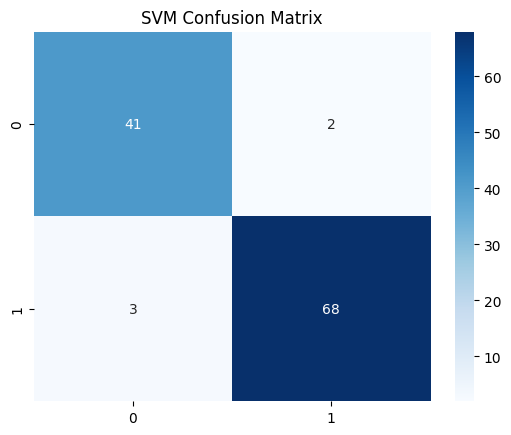

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



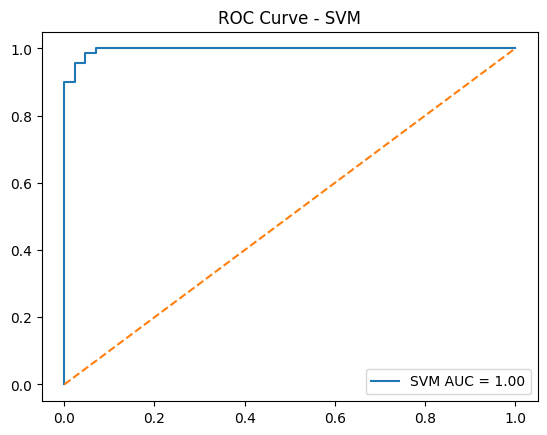

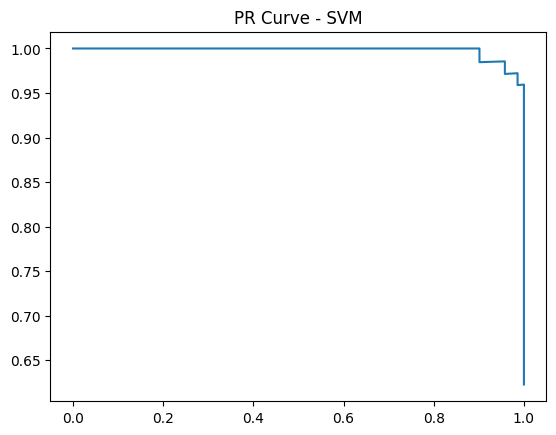

In [2]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve, auc

# Model
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(X_train, y_train)

# Prediction
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:,1]

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("SVM Confusion Matrix")
plt.show()

# Report
print(classification_report(y_test, y_pred))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label="SVM AUC = %.2f" % auc(fpr, tpr))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve - SVM")
plt.show()

# Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.title("PR Curve - SVM")
plt.show()

KNN Accuracy: 0.9473684210526315


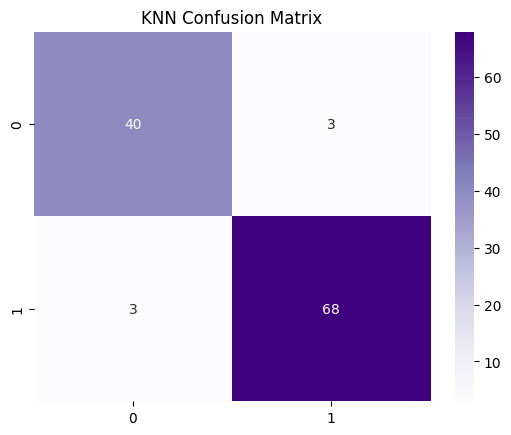

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



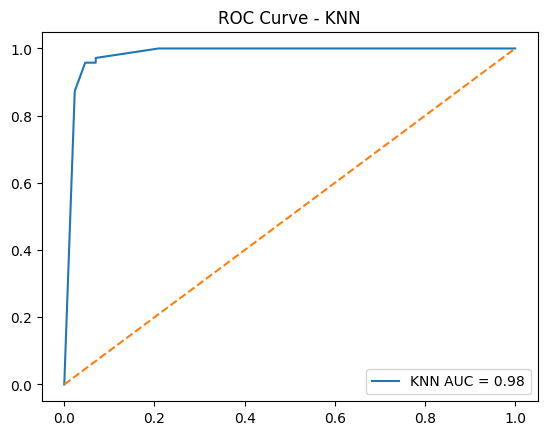

In [3]:
from sklearn.neighbors import KNeighborsClassifier

# Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Prediction
y_pred_knn = knn_model.predict(X_test)
y_prob_knn = knn_model.predict_proba(X_test)[:,1]

# Accuracy
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Purples')
plt.title("KNN Confusion Matrix")
plt.show()

# Report
print(classification_report(y_test, y_pred_knn))

# ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
plt.plot(fpr_knn, tpr_knn, label="KNN AUC = %.2f" % auc(fpr_knn, tpr_knn))
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve - KNN")
plt.show()

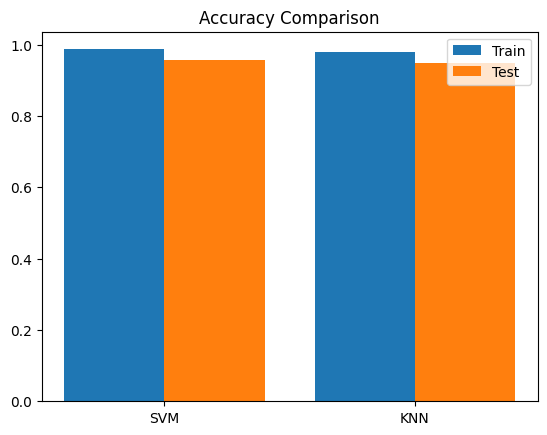

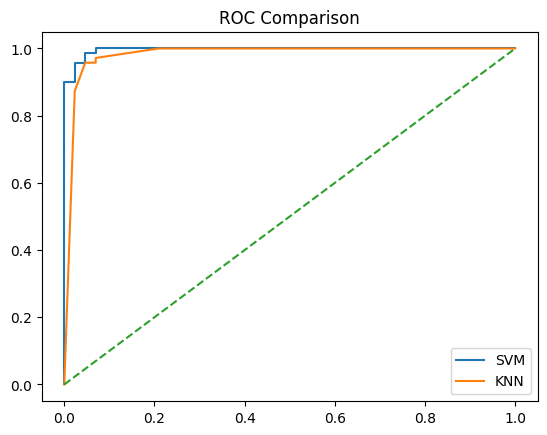

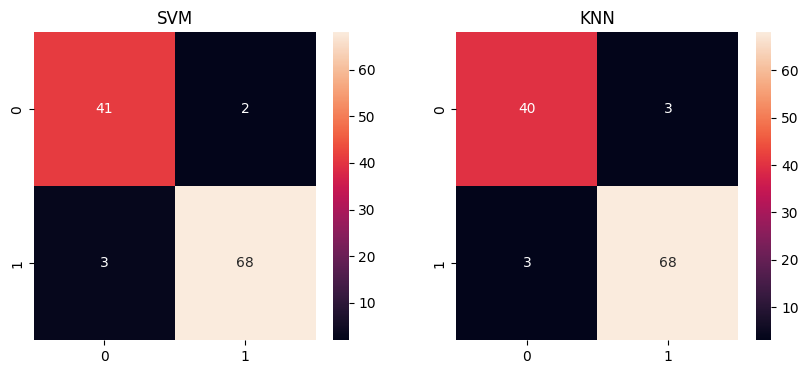

In [4]:
# Accuracy Comparison
svm_train = svm_model.score(X_train, y_train)
svm_test = accuracy_score(y_test, y_pred)

knn_train = knn_model.score(X_train, y_train)
knn_test = accuracy_score(y_test, y_pred_knn)

models = ['SVM', 'KNN']
train_scores = [svm_train, knn_train]
test_scores = [svm_test, knn_test]

x = np.arange(len(models))

plt.bar(x-0.2, train_scores, 0.4, label="Train")
plt.bar(x+0.2, test_scores, 0.4, label="Test")
plt.xticks(x, models)
plt.legend()
plt.title("Accuracy Comparison")
plt.show()

# ROC Comparison
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_knn, tpr_knn, label="KNN")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Comparison")
plt.show()

# Confusion Matrix Comparison
fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, ax=axes[0])
axes[0].set_title("SVM")

sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, ax=axes[1])
axes[1].set_title("KNN")

plt.show()